# CALCULATING SNN FOR ENVI LATENT ONLY AND USING IT TO INFER METACELLS

In [55]:

from __future__ import annotations
from typing import TYPE_CHECKING
from warnings import warn
import logging
import os
import warnings
import datetime

os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'  # FATA

warnings.filterwarnings('ignore')
logging.getLogger('tensorflow').setLevel(logging.FATAL)
logging.getLogger('tensorflow_probability').setLevel(logging.FATAL)

from IPython.display import clear_output


import numpy as np
import pandas as pd
import scanpy as sc
import colorcet
import sklearn.neighbors
import scipy.sparse
import numpy as np
#from scipy.sparse import csr_matrix
from sklearn.neighbors import NearestNeighbors
from typing import Optional
from typing import Union
import numpy as np
import pandas as pd
from anndata import AnnData  # type: ignore
from numpy.typing import NDArray
import umap.umap_ as umap
import matplotlib
import matplotlib.pyplot as plt
import colorcet
import sklearn.neighbors
       # Plotting ENVI latent and COVET matrices
import umap
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.sparse

import metacells.parameters as pr
import metacells.utilities as ut
from scipy.sparse import load_npz

In [56]:
def compute_knn_indices(
    X: np.ndarray, n_neighbors: int
) -> tuple[np.ndarray, np.ndarray]:
    nbrs = NearestNeighbors(n_neighbors=n_neighbors, algorithm='kd_tree').fit(X)
    distances, indices = nbrs.kneighbors(X)
    return indices, distances

def snn_matrix(
    indices: np.ndarray,
    n_neighbors: int
) -> np.ndarray:
    n_samples = indices.shape[0]
    snn = np.zeros((n_samples, n_samples), dtype=np.float32)
    
    for i in range(n_samples):
        for j in range(i + 1, n_samples):
            nni = indices[i]
            nnj = indices[j]
            shared = np.intersect1d(nni, nnj)
            s = [0]
            for shared_knn in shared:
                s.append(n_neighbors - 0.5 * (np.where(nni == shared_knn)[0][0] + np.where(nnj == shared_knn)[0][0]))
            snn[i, j] = max(s)
            snn[j, i] = snn[i, j]
    return snn
def snn_matrix_2(indices: np.ndarray, n_neighbors: int) -> np.ndarray:
    n_samples = indices.shape[0]
    snn = np.zeros((n_samples, n_samples), dtype=np.float32)

    for i in range(n_samples):
        for j in range(i + 1, n_samples):
            nni = indices[i]
            nnj = indices[j]
            shared = np.intersect1d(nni, nnj)

            print(f"Shared neighbors between {i} and {j}: {shared}")  # Debugging

            if len(shared) == 0:  # If no shared neighbors, skip
                continue  

            s = [0]
            for shared_knn in shared:
                s.append(n_neighbors - 0.5 * (np.where(nni == shared_knn)[0][0] + np.where(nnj == shared_knn)[0][0]))

            snn[i, j] = max(s)
            snn[j, i] = snn[i, j]

    return snn
def snn_matrix_2(indices: np.ndarray, n_neighbors: int) -> np.ndarray:
    n_samples = indices.shape[0]
    snn = np.zeros((n_samples, n_samples), dtype=np.float32)

    for i in range(n_samples):
        nni = indices[i]

        for j in range(i + 1, n_samples):
            nnj = indices[j]

            # Efficient shared neighbor check
            shared = nni[np.isin(nni, nnj)]

            if len(shared) == 0:
                continue  # No shared neighbors, skip

            s = [0]
            for shared_knn in shared:
                pos_i = np.where(nni == shared_knn)[0]
                pos_j = np.where(nnj == shared_knn)[0]

                if len(pos_i) > 0 and len(pos_j) > 0:
                    s.append(n_neighbors - 0.5 * (pos_i[0] + pos_j[0]))

            snn[i, j] = max(s)
            snn[j, i] = snn[i, j]

    # Ensure self-connections are represented
    np.fill_diagonal(snn, n_neighbors)

    return snn


In [57]:
sc_ad=sc.read_h5ad("/Users/anushka/Documents/Undergraduate-Project/obsm-anndata-file/sc_data.h5ad")
st_ad=sc.read_h5ad("/Users/anushka/Documents/Undergraduate-Project/obsm-anndata-file/st_data.h5ad")
envi_latent_st = st_ad.obsm['envi_latent']
envi_latent_sc = sc_ad.obsm['envi_latent']

print(f"st_ad envi_latent shape: {envi_latent_st.shape}")
print(f"sc_ad envi_latent shape: {envi_latent_sc.shape}")

st_ad envi_latent shape: (18516, 512)
sc_ad envi_latent shape: (7416, 512)


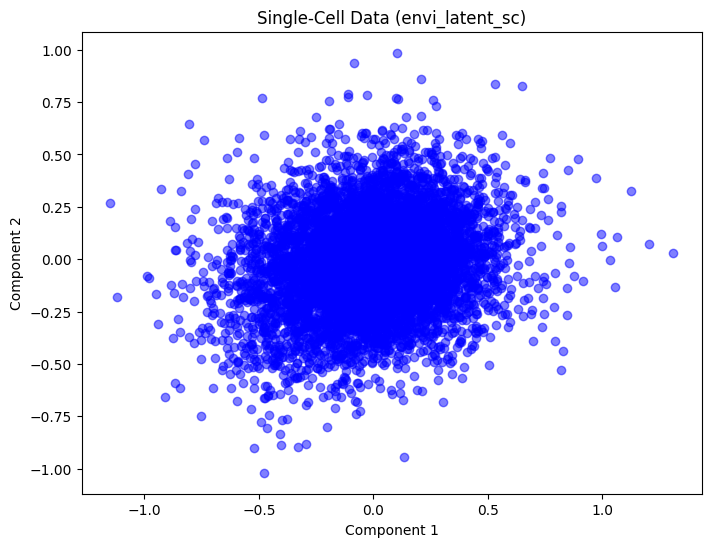

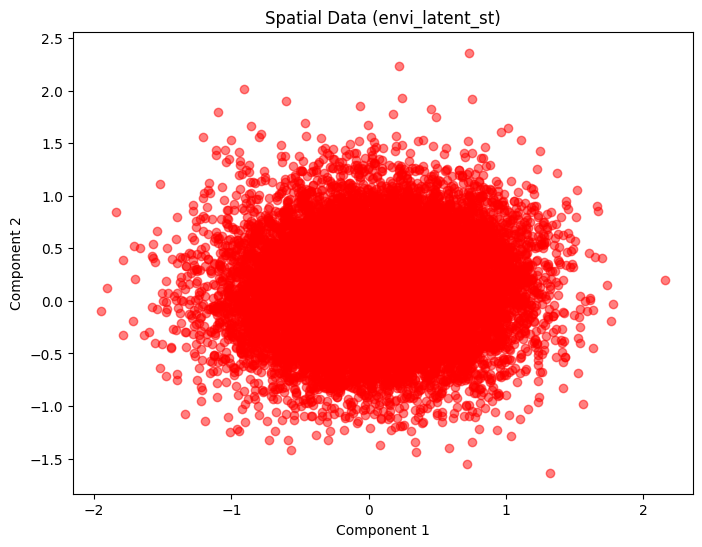

In [42]:
import matplotlib.pyplot as plt

# Plot Single-Cell Data
plt.figure(figsize=(8, 6))
plt.scatter(envi_latent_sc[:, 0], envi_latent_sc[:, 1], c='blue', alpha=0.5)
plt.xlabel("Component 1")
plt.ylabel("Component 2")
plt.title("Single-Cell Data (envi_latent_sc)")
plt.show()

# Plot Spatial Data
plt.figure(figsize=(8, 6))
plt.scatter(envi_latent_st[:, 0], envi_latent_st[:, 1], c='red', alpha=0.5)
plt.xlabel("Component 1")
plt.ylabel("Component 2")
plt.title("Spatial Data (envi_latent_st)")
plt.show()


In [ ]:
envi_latent_st

array([[-0.13552888,  0.05128916, -0.01799968, ...,  0.31307203,
         0.66074383, -0.22053547],
       [ 0.2457473 ,  0.27358943,  0.267426  , ...,  0.64922696,
        -0.43311796, -0.05128566],
       [ 0.33170316,  0.43495297,  0.05492263, ..., -0.56212085,
        -0.14697462,  0.35447058],
       ...,
       [-0.00809197,  0.30837688,  0.5936734 , ..., -0.2005235 ,
         0.22823815, -0.25320795],
       [ 0.22977303, -0.25840616, -0.2031456 , ..., -0.18411052,
        -0.49793604, -0.10384995],
       [ 0.18616462,  0.04631992,  0.4965636 , ..., -0.09588898,
         0.2144121 , -0.00381352]], dtype=float32)

In [24]:
envi_latent_sc

array([[ 5.45097232e-01,  1.49812788e-01, -5.09735644e-02, ...,
         3.62423837e-01, -3.89712751e-02, -7.99230635e-02],
       [ 1.69814110e-01,  1.34617656e-01, -3.67299616e-02, ...,
        -5.96621707e-02, -3.36963031e-03, -8.69654268e-02],
       [ 2.00322017e-01,  1.64995521e-01,  1.33892387e-01, ...,
         3.99893299e-02, -3.12752992e-01,  6.48150265e-01],
       ...,
       [-2.40167737e-01, -1.01001859e-02,  2.00647682e-01, ...,
        -1.18603684e-01, -1.66670308e-01,  1.47807628e-01],
       [ 3.31372232e-03, -1.10613286e-01, -1.46694988e-01, ...,
        -3.48930135e-02,  3.15234303e-01,  3.28641623e-01],
       [ 1.38930202e-01, -1.88755661e-01,  1.25579089e-01, ...,
         7.78009892e-02,  3.81513499e-04,  5.80687337e-02]], dtype=float32)

In [10]:
combined_envi_latent = np.concatenate([envi_latent_sc, envi_latent_st], axis=0)
print(combined_envi_latent)

[[ 0.54509723  0.14981279 -0.05097356 ...  0.36242384 -0.03897128
  -0.07992306]
 [ 0.16981411  0.13461766 -0.03672996 ... -0.05966217 -0.00336963
  -0.08696543]
 [ 0.20032202  0.16499552  0.13389239 ...  0.03998933 -0.312753
   0.64815027]
 ...
 [-0.00809197  0.30837688  0.5936734  ... -0.2005235   0.22823815
  -0.25320795]
 [ 0.22977303 -0.25840616 -0.2031456  ... -0.18411052 -0.49793604
  -0.10384995]
 [ 0.18616462  0.04631992  0.4965636  ... -0.09588898  0.2144121
  -0.00381352]]


In [38]:
combined_envi_latent.shape

(25932, 512)

In [11]:
def calculate_sparsity(matrix):
    total_elements = matrix.size
    zero_elements = np.count_nonzero(matrix == 0)
    sparsity = (zero_elements / total_elements) * 100
    print(f"Sparsity: {sparsity:.2f}%")
    print("Zero elements=", zero_elements)
    return sparsity

print("Sparsity of combined_envi_latent:")
calculate_sparsity(combined_envi_latent)


Sparsity of combined_envi_latent:
Sparsity: 0.00%
Zero elements= 0


0.0

# SO basically the data is not spare. we do not have a zero in the dataset and the data is dense af

In [12]:
fit = umap.UMAP(n_neighbors=100, min_dist=0.1, n_components=2)
UMAPEmb = fit.fit_transform(combined_envi_latent)

In [13]:
st_ad.obsm['latent_umap'] = UMAPEmb[:st_ad.shape[0]]
sc_ad.obsm['latent_umap'] = UMAPEmb[st_ad.shape[0]:]

In [14]:
import anndata as ad
cell_types_sc = sc_ad.obs["cell_type"].values
cell_types_st = st_ad.obs["cell_type"].values
combined_cell_types = np.concatenate((cell_types_sc, cell_types_st), axis=0)

adata = ad.AnnData(X=combined_envi_latent)
adata.obs["cell_type"] = combined_cell_types


In [15]:
adata

AnnData object with n_obs × n_vars = 25932 × 512
    obs: 'cell_type'

In [16]:
raw_data = AnnData(adata.X.copy())
raw_data.obs_names, raw_data.var_names = adata.obs_names, adata.var_names
adata.raw = raw_data

sc.pp.normalize_per_cell(adata)
sc.pp.highly_variable_genes(adata, n_top_genes=2048)



In [17]:
sc.pp.neighbors(adata, n_neighbors=5)
sc.tl.umap(adata)

In [18]:
indices, distances = compute_knn_indices(combined_envi_latent, n_neighbors=15)


In [20]:
print("Indices: ", indices)
print("Distances: ", distances)

Indices:  [[    0  3091  6692 ...  4346  3952  4950]
 [    1  7011  6796 ...   442  6850  7306]
 [    2  4440  4090 ...  5286  7014   645]
 ...
 [25929  7832  9233 ...  7284 22317  9464]
 [25930 18605 14278 ...  4075  4654 13134]
 [25931 23511 13914 ...  5098  4309 24276]]
Distances:  [[ 0.          5.47725476  5.50796722 ...  6.02998628  6.03952654
   6.05566414]
 [ 0.          4.95790715  5.1062969  ...  5.42940075  5.47483284
   5.47778131]
 [ 0.          3.95879688  4.57767449 ...  5.18173177  5.2437132
   5.24690745]
 ...
 [ 0.          8.40889324  9.61072271 ... 10.39714577 10.42764172
  10.4283101 ]
 [ 0.         10.59960558 11.31296301 ... 11.668383   11.70930099
  11.76850546]
 [ 0.         10.2162494  10.41680195 ... 11.84110702 11.88605745
  11.89311072]]


In [21]:
snn_envi = snn_matrix(indices, n_neighbors=5)

In [23]:
snn_envi

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], dtype=float32)

## This did not work out it seems 

In [18]:
envi_latent_sc

array([[ 5.45097232e-01,  1.49812788e-01, -5.09735644e-02, ...,
         3.62423837e-01, -3.89712751e-02, -7.99230635e-02],
       [ 1.69814110e-01,  1.34617656e-01, -3.67299616e-02, ...,
        -5.96621707e-02, -3.36963031e-03, -8.69654268e-02],
       [ 2.00322017e-01,  1.64995521e-01,  1.33892387e-01, ...,
         3.99893299e-02, -3.12752992e-01,  6.48150265e-01],
       ...,
       [-2.40167737e-01, -1.01001859e-02,  2.00647682e-01, ...,
        -1.18603684e-01, -1.66670308e-01,  1.47807628e-01],
       [ 3.31372232e-03, -1.10613286e-01, -1.46694988e-01, ...,
        -3.48930135e-02,  3.15234303e-01,  3.28641623e-01],
       [ 1.38930202e-01, -1.88755661e-01,  1.25579089e-01, ...,
         7.78009892e-02,  3.81513499e-04,  5.80687337e-02]], dtype=float32)

In [9]:
fit = umap.UMAP(n_neighbors=100, min_dist=0.1, n_components=2)
UMAPEmb = fit.fit_transform(envi_latent_sc)

In [11]:
import anndata as ad
cell_types_sc = sc_ad.obs["cell_type"].values

adata = ad.AnnData(X=envi_latent_sc)
adata.obs["cell_type"] = cell_types_sc

In [13]:
raw_data = AnnData(adata.X.copy())
raw_data.obs_names, raw_data.var_names = adata.obs_names, adata.var_names
adata.raw = raw_data

sc.pp.normalize_per_cell(adata)
sc.pp.highly_variable_genes(adata, n_top_genes=2048)
sc.pp.log1p(adata)


In [15]:
adata

AnnData object with n_obs × n_vars = 3531 × 512
    obs: 'cell_type', 'n_counts'
    var: 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'hvg', 'log1p'

In [16]:
import numpy as np
print(np.isnan(adata.X).sum())


71148


In [22]:
print(adata.X.shape)

(3531, 512)


In [23]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy="mean")  # You can also use "median" or "most_frequent"
adata.X = imputer.fit_transform(adata.X)


In [24]:
sc.pp.neighbors(adata, n_neighbors=15)
sc.tl.umap(adata)

In [26]:
indices, distances = compute_knn_indices(envi_latent_sc, n_neighbors=15)


In [27]:
print(indices)

[[   0 3091 6692 ... 4346 3952 4950]
 [   1 7011 6796 ...  442 6850 7306]
 [   2 4440 4090 ... 5286 7014  645]
 ...
 [7413 3089 6044 ... 3049 1296  872]
 [7414 2408 6093 ... 5702 5298 3379]
 [7415 2682 6926 ... 7407 3457 1361]]


In [ ]:
snn_envi = snn_matrix_2(indices, n_neighbors=5)

# My approach 


###    Why MNN Helps
### Mutual Nearest Neighbors (MNN) algorithms like BBKNN and Scanorama correct for batch effects by:

### Identifying mutual neighbors across datasets that represent biologically similar cells.Aligning the datasets using these shared neighbors as anchors.Preserving local structures while minimizing artificial batch-induced separations.This way, after applying MNN, biological signals become more prominent, and cells with similar transcriptomic profiles are clustered together, regardless of their batch of origin.

In [58]:
import scanorama
import scanpy as sc


# Convert to AnnData objects for Scanorama
adata_sc = sc.AnnData(envi_latent_sc)
adata_st = sc.AnnData(envi_latent_st)

# Add batch labels
adata_sc.obs['batch'] = 'scRNA'
adata_st.obs['batch'] = 'Spatial'
# Perform Scanorama integration



Found 512 genes among all datasets
[[0.         0.88362999]
 [0.         0.        ]]
Processing datasets (0, 1)


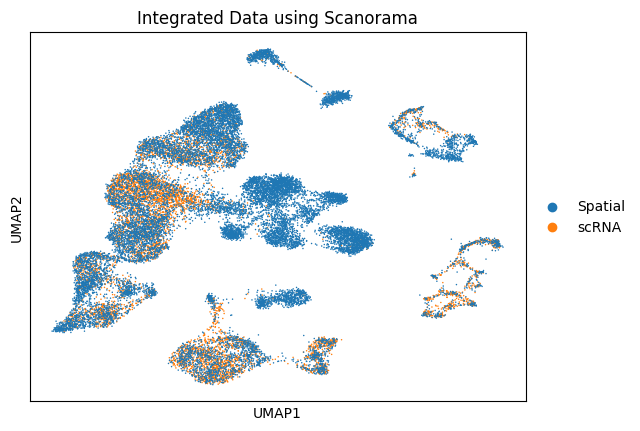

In [59]:
# Perform integration using Scanorama
integrated_data = scanorama.correct_scanpy([adata_sc, adata_st])

# Combine integrated data
adata_integrated = sc.concat(integrated_data, join='inner')

# Perform PCA, neighbors, and UMAP for visualization
sc.pp.pca(adata_integrated)
sc.pp.neighbors(adata_integrated)
sc.tl.umap(adata_integrated)

# Visualize
sc.pl.umap(adata_integrated, color='batch', title='Integrated Data using Scanorama')


In [60]:
adata_integrated

AnnData object with n_obs × n_vars = 25932 × 512
    obs: 'batch'
    uns: 'pca', 'neighbors', 'umap', 'batch_colors'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    obsp: 'distances', 'connectivities'

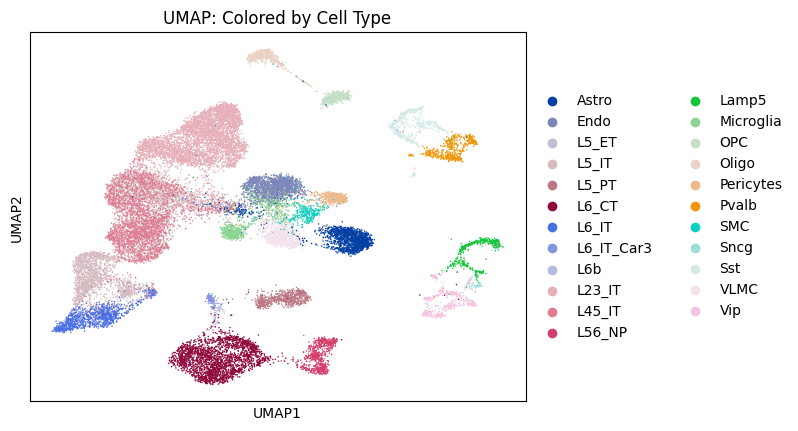

In [61]:
# Add the combined cell types to the integrated data
adata_integrated.obs['cell_type'] = combined_cell_types

# Visualize UMAP colored by cell type
sc.pl.umap(adata_integrated, color='cell_type', title='UMAP: Colored by Cell Type')


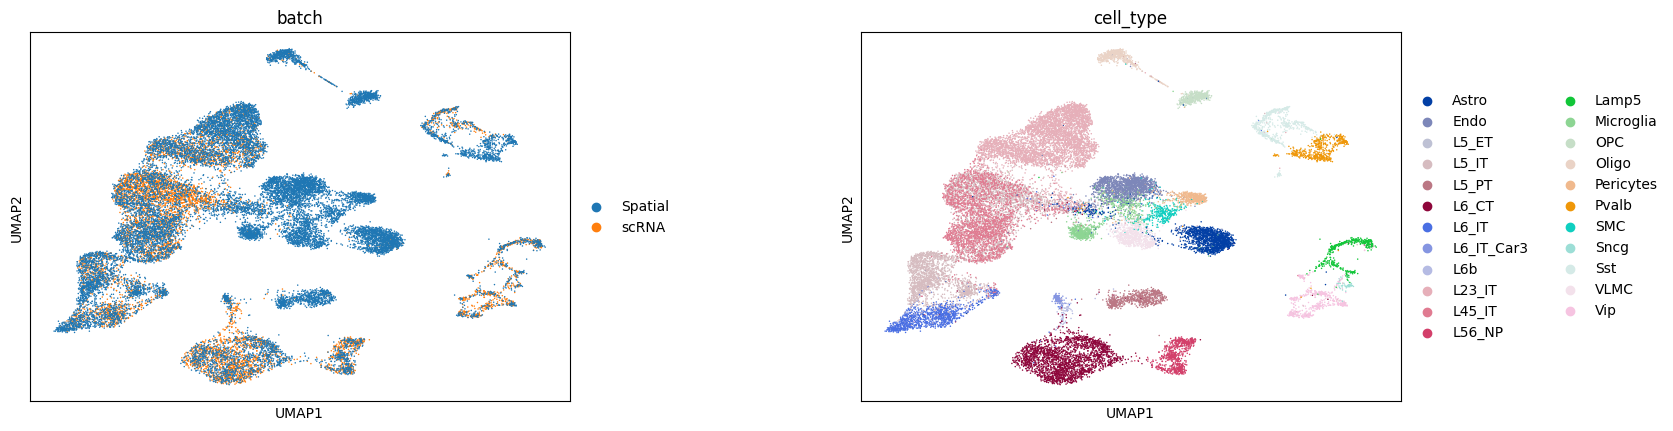

In [62]:
sc.pl.umap(adata_integrated, color=['batch', 'cell_type'], wspace=0.4)
